Installing packages

In [1]:
!pip install rdkit pandas numpy matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 54.3 MB/s eta 0:00:00:00:0100:01


Cloning repo

In [2]:
import os

REPO_ROOT = "/content/REINVENT_Boltz_Pipeline"

if not os.path.exists(REPO_ROOT):
    !git clone https://github.com/ibrahimwichka/REINVENT_Boltz_Pipeline.git {REPO_ROOT}
else:
    !git -C {REPO_ROOT} pull origin main

print(os.path.exists(REPO_ROOT))

Cloning into '/content/REINVENT_Boltz_Pipeline'...
remote: Enumerating objects: 178, done.
remote: Counting objects: 100% (178/178), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 178 (delta 49), reused 148 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (178/178), 24.48 MiB | 28.88 MiB/s, done.
Resolving deltas: 100% (49/49), done.
True


Setting target, iteration, and data paths

In [7]:
from pathlib import Path

# --- The only lines that change between targets/iterations ---
TARGET_NAME = "CDK2" # or "P38_MAPK14"
ITERATION = 1
ACTIVES_BASELINE = "CDK2_actives_baseline_profile.csv" # or "P38_MAPK14_..."
ANALYSIS_SUBFOLDER = "CDK2_analysis" #or "P38_MAPK14_analysis"
# ---------------------------------------------------------------

REPO_ROOT_PATH = Path(REPO_ROOT)
GENERATED_PATH = (REPO_ROOT_PATH / "iterations" / TARGET_NAME / str(ITERATION)
/ "generation" / "generated_molecules.csv")
BASELINE_PATH = (REPO_ROOT_PATH / "target_mols" / TARGET_NAME / "analysis"
/ ANALYSIS_SUBFOLDER / ACTIVES_BASELINE)
ANALYSIS_DIR = (REPO_ROOT_PATH / "iterations" / TARGET_NAME / str(ITERATION)
/ "analysis")
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print(GENERATED_PATH.exists())
print(BASELINE_PATH.exists())
print(ANALYSIS_DIR)

True
True
/content/REINVENT_Boltz_Pipeline/iterations/CDK2/1/analysis


Imports

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, Crippen, Lipinski, QED, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator, Draw
from rdkit.Chem import FilterCatalog
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

In [9]:
!mkdir -p /content/sa_score
!curl -L -o /content/sa_score/sascorer.py \
    https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py
!curl -L -o /content/sa_score/fpscores.pkl.gz \
    https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  5913  100  5913    0     0  32971      0 --:--:-- --:--:-- --:--:-- 33033
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 3758k  100 3758k    0     0  7625k      0 --:--:-- --:--:-- --:--:-- 7638k


Loading generated molecules and actives baseline

In [10]:
generated_raw = pd.read_csv(GENERATED_PATH)
print(TARGET_NAME, "Iteration", ITERATION, "generated:", generated_raw.shape)
generated_raw.head()

baseline = pd.read_csv(BASELINE_PATH)
print(TARGET_NAME, "actives baseline:", baseline.shape)
baseline.head()

CDK2 Iteration 1 generated: (4877, 3)
CDK2 actives baseline: (1402, 20)


,canonical_smiles,MW,cLogP,HBD,HBA,TPSA,QED,SA_score,scaffold,has_hydroxyl,has_amine,has_carbonyl,has_amide,has_halogen_F,has_halogen_Cl,has_halogen_Br,has_aromatic_ring,has_piperidine,has_piperazine,has_morpholine
0,O=[N+]([O-])c1cccc(Nc2nccc(-c3cnn4ncccc34)n2)c1,333.311,2.83810,1,7,111.14,0.451249,2.562189,c1ccc(Nc2nccc(-c3cnn4ncccc34)n2)cc1,False,True,False,False,False,False,False,True,False,False,False
1,NS(=O)(=O)c1ccc(Nc2cc(-c3ccc([N+](=O)[O-])cc3)...,359.367,2.37590,3,6,144.01,0.471015,2.220594,c1ccc(Nc2cc(-c3ccccc3)[nH]n2)cc1,False,True,False,False,False,False,False,True,False,False,False
2,Nc1ccc(-c2cc(Nc3ccc(S(N)(=O)=O)cc3)[nH]n2)cc1,329.385,2.04990,4,5,126.89,0.544792,2.326835,c1ccc(Nc2cc(-c3ccccc3)n[nH]2)cc1,False,True,False,False,False,False,False,True,False,False,False
3,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,466.541,4.35400,2,4,69.45,0.405842,4.953656,O=C1NCc2c1c1c3ccccc3n3c1c1c2c2ccccc2n1C1CCC[C@...,False,True,True,True,False,False,False,True,False,False,False
4,CC(=O)NC1CN(c2ccc(Nc3ncc(F)c(-c4cnc(C)n4C(C)C)...,423.496,3.43682,2,6,87.97,0.631580,2.756320,c1cc(-c2cnc[nH]2)nc(Nc2ccc(N3CCC3)cc2)n1,False,True,True,True,True,False,False,True,False,False,False


Cleaning and canonicalizing generated molecules

In [11]:
def canonicalize(smiles):
# Return a canonical SMILES string, or None if RDKit can’t parse it
    if not isinstance(smiles, str) or not smiles.strip():
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol)

def clean_generated(df_raw, smiles_col):
    df = df_raw.copy()
    df["canonical_smiles"] = df[smiles_col].apply(canonicalize)
    n_before = len(df)
    df = df.dropna(subset=["canonical_smiles"])
    df = df.drop_duplicates(subset=["canonical_smiles"]).reset_index(drop=True)
    print(f"kept {len(df)} of {n_before} rows after canonicalization + dedup")
    return df

gen_df = clean_generated(generated_raw, smiles_col="SMILES")

kept 4877 of 4877 rows after canonicalization + dedup


Recomputing descriptors, QED, SA score, scaffold, and functional
groups

In [13]:
def add_descriptors(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["MW"] = [Descriptors.MolWt(m) for m in mols]
    df["cLogP"] = [Crippen.MolLogP(m) for m in mols]
    df["HBD"] = [Lipinski.NumHDonors(m) for m in mols]
    df["HBA"] = [Lipinski.NumHAcceptors(m) for m in mols]
    df["TPSA"] = [rdMolDescriptors.CalcTPSA(m) for m in mols]
    return df

def add_qed(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["QED"] = [QED.qed(m) for m in mols]
    return df


import sys
sys.path.append("/content/sa_score")
import sascorer

def add_sa_score(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["SA_score"] = [sascorer.calculateScore(m) for m in mols]
    return df

def add_scaffold(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["scaffold"] = [
        Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(m)) for m in mols
        ]
    return df

FUNCTIONAL_GROUP_SMARTS = {
    "hydroxyl": "[OX2H]",
    "amine": "[NX3;H2,H1;!$(NC=O)]",
    "carbonyl": "[CX3]=[OX1]",
    "amide": "C(=O)N",
    "halogen_F": "[#9]",
    "halogen_Cl": "[#17]",
    "halogen_Br": "[#35]",
    "aromatic_ring": "a1aaaaa1",
    "piperidine": "C1CCNCC1",
    "piperazine": "C1CNCCN1",
    "morpholine": "C1COCCN1",
    }
FUNCTIONAL_GROUP_PATTERNS = {
name: Chem.MolFromSmarts(smarts) for name, smarts in FUNCTIONAL_GROUP_SMARTS.items()
}

def add_functional_group_flags(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    for name, patt in FUNCTIONAL_GROUP_PATTERNS.items():
        df[f"has_{name}"] = [m.HasSubstructMatch(patt) for m in mols]
    return df

gen_df = add_descriptors(gen_df)
gen_df = add_qed(gen_df)
gen_df = add_sa_score(gen_df)
gen_df = add_scaffold(gen_df)
gen_df = add_functional_group_flags(gen_df)

gen_df[["MW", "cLogP", "HBD", "HBA", "TPSA", "QED", "SA_score"]].describe()

,MW,cLogP,HBD,HBA,TPSA,QED,SA_score
count,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000
mean,356.315799,3.311998,1.285216,4.177363,68.034084,0.608739,2.996304
std,128.891722,2.308438,1.167676,2.073979,36.810557,0.221624,0.791418
min,87.078000,-9.110400,0.000000,0.000000,0.000000,0.011203,1.430026
25%,266.772000,1.949200,1.000000,3.000000,43.370000,0.459394,2.436342
50%,336.355000,3.056300,1.000000,4.000000,64.150000,0.655792,2.840714
75%,423.192000,4.301000,2.000000,5.000000,86.630000,0.788981,3.395005
max,1311.789000,26.279400,17.000000,24.000000,468.230000,0.947447,7.755449


Overlaid distribution comparisons

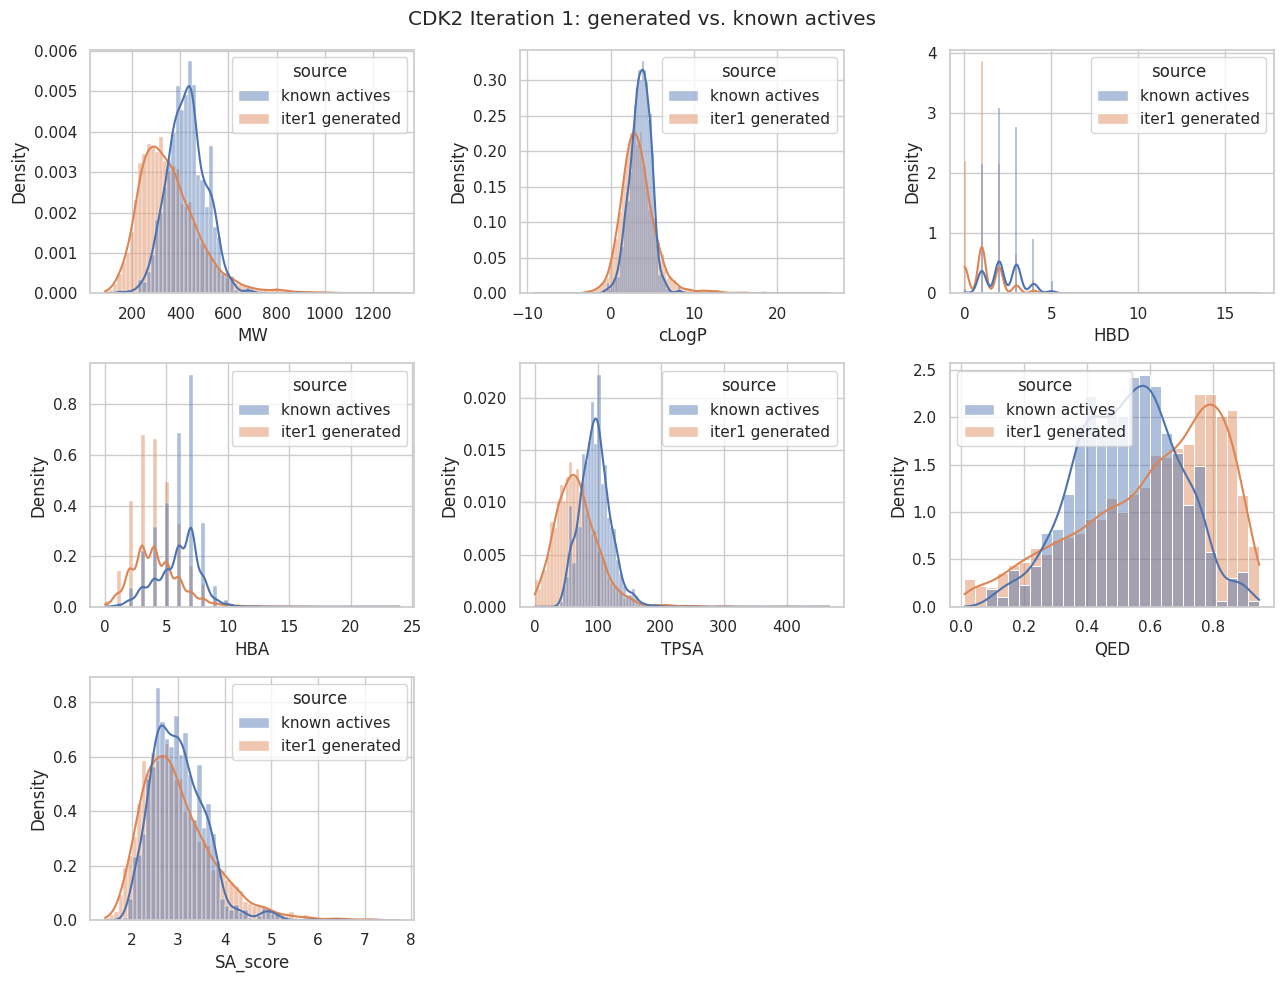

In [14]:
DESCRIPTOR_COLS = ["MW", "cLogP", "HBD", "HBA", "TPSA", "QED", "SA_score"]

compare_long = pd.concat([
    baseline[DESCRIPTOR_COLS].assign(source="known actives"),
    gen_df[DESCRIPTOR_COLS].assign(source=f"iter{ITERATION} generated"),
    ], ignore_index=True)

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.flat, DESCRIPTOR_COLS):
    sns.histplot(data=compare_long, x=col, hue="source", stat="density", 
                 common_norm=False, kde=True, alpha=0.45, ax=ax)
for ax in axes.flat[len(DESCRIPTOR_COLS):]:
    ax.set_visible(False)
fig.suptitle(f"{TARGET_NAME} Iteration {ITERATION}: generated vs. known actives")
fig.tight_layout()
fig.savefig(ANALYSIS_DIR / f"{TARGET_NAME}_iter{ITERATION}_descriptor_comparison.png", 
            dpi=150, bbox_inches="tight")
plt.show()

Scaffold diversity and overlap

CDK2 iter1: 3726 unique scaffolds across 4877 generated molecules
CDK2 actives: 603 unique scaffolds across 1402 molecules
Scaffolds appearing in BOTH sets: 8


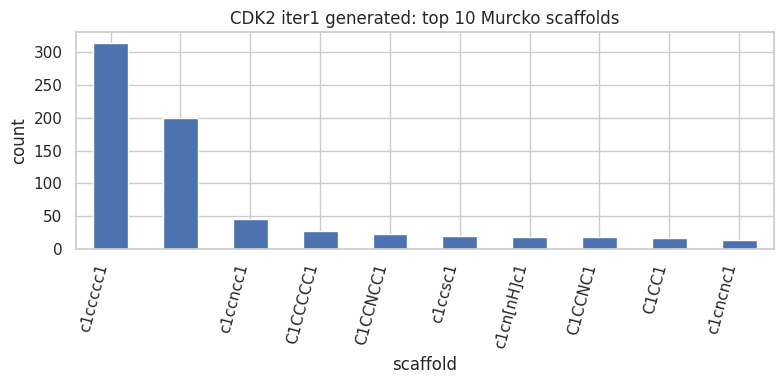

In [15]:
n_gen_scaffolds = gen_df["scaffold"].nunique()
n_act_scaffolds = baseline["scaffold"].nunique()
shared_scaffolds = set(gen_df["scaffold"]) & set(baseline["scaffold"])

print(f"{TARGET_NAME} iter{ITERATION}: {n_gen_scaffolds} unique scaffolds "
    f"across {len(gen_df)} generated molecules")
print(f"{TARGET_NAME} actives: {n_act_scaffolds} unique scaffolds "
    f"across {len(baseline)} molecules")
print(f"Scaffolds appearing in BOTH sets: {len(shared_scaffolds)}")

top_gen_scaffolds = gen_df["scaffold"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 4))
top_gen_scaffolds.plot(kind="bar", ax=ax)
ax.set_ylabel("count")
ax.set_title(f"{TARGET_NAME} iter{ITERATION} generated: top 10 Murcko scaffolds")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
fig.savefig(ANALYSIS_DIR / f"{TARGET_NAME}_iter{ITERATION}_top_scaffolds.png", 
            dpi=150, bbox_inches="tight")
plt.show()

Functional group frequency comparison

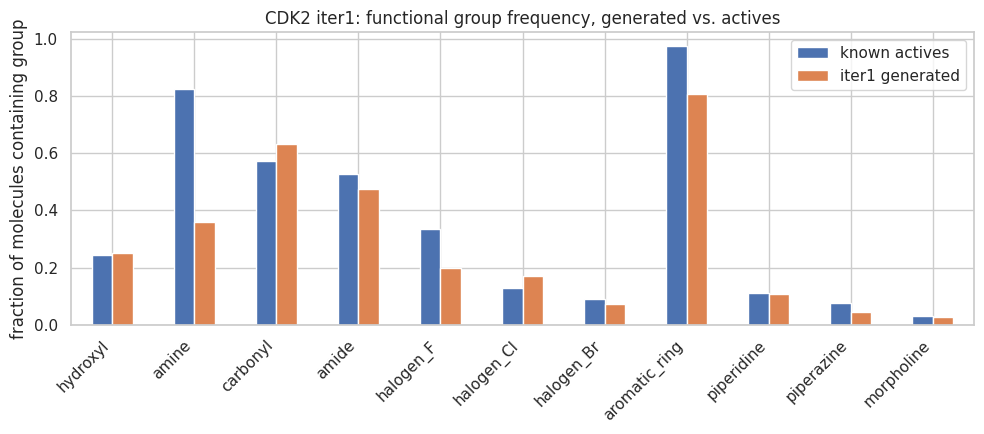

In [16]:
flag_cols = [f"has_{name}" for name in FUNCTIONAL_GROUP_SMARTS]

freq_compare = pd.DataFrame({
    "known actives": baseline[flag_cols].mean(),
    f"iter{ITERATION} generated": gen_df[flag_cols].mean(),
    })
freq_compare.index = [c.replace("has_", "") for c in freq_compare.index]

fig, ax = plt.subplots(figsize=(10, 4.5))
freq_compare.plot(kind="bar", ax=ax)
ax.set_ylabel("fraction of molecules containing group")
ax.set_title(f"{TARGET_NAME} iter{ITERATION}: functional group frequency, " 
             "generated vs. actives")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(ANALYSIS_DIR / f"{TARGET_NAME}_iter{ITERATION}_functional_group_frequency.png", 
            dpi=150, bbox_inches="tight")
plt.show()

Cross-set Tanimoto similarity to known actives

In [20]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def add_fingerprints(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["fingerprint"] = [morgan_gen.GetFingerprint(m) for m in mols]
    return df

gen_df = add_fingerprints(gen_df)
baseline_fps_df = add_fingerprints(baseline.rename(columns={"canonical_smiles": 
        "canonical_smiles"}))
active_fps = list(baseline_fps_df["fingerprint"])

def nearest_active(fp):
    #Return (max Tanimoto similarity, index into baseline of the nearest active).
    sims = DataStructs.BulkTanimotoSimilarity(fp, active_fps)
    best_idx = int(np.argmax(sims))
    return sims[best_idx], best_idx

results = [nearest_active(fp) for fp in gen_df["fingerprint"]]
gen_df["nearest_active_sim"] = [r[0] for r in results]
gen_df["nearest_active_idx"] = [r[1] for r in results]

print(f"{TARGET_NAME} iter{ITERATION}: mean nearest-active Tanimoto = "
      f"{gen_df['nearest_active_sim'].mean():.3f}, "
      f"max = {gen_df['nearest_active_sim'].max():.3f}")

CDK2 iter1: mean nearest-active Tanimoto = 0.232, max = 0.548


Rediscovery hit detection

In [21]:
THETA_HIT = 0.85 # research plan Section 1.5: near-identical scaffold
THETA_EXACT = 1.0 # exact canonical SMILES match

hits = gen_df[gen_df["nearest_active_sim"] >= THETA_HIT].copy()
exact_hits = gen_df[gen_df["nearest_active_sim"] >= THETA_EXACT].copy()

print(f"{TARGET_NAME} iter{ITERATION}: {len(hits)} rediscovery hit(s) "
    f"(sim >= {THETA_HIT}) out of {len(gen_df)} generated molecules")
print(f" of which {len(exact_hits)} are exact matches (sim = 1.0)")

if len(hits) == 0:
    print("\nNo hits yet -- expected for Iteration 1. See the closest pairs below "
    "instead; re-run this exact cell on later iterations to watch this "
    "number move.")


CDK2 iter1: 0 rediscovery hit(s) (sim >= 0.85) out of 4877 generated molecules
 of which 0 are exact matches (sim = 1.0)

No hits yet -- expected for Iteration 1. See the closest pairs below instead; re-run this exact cell on later iterations to watch this number move.


Visualizing the closest pairs

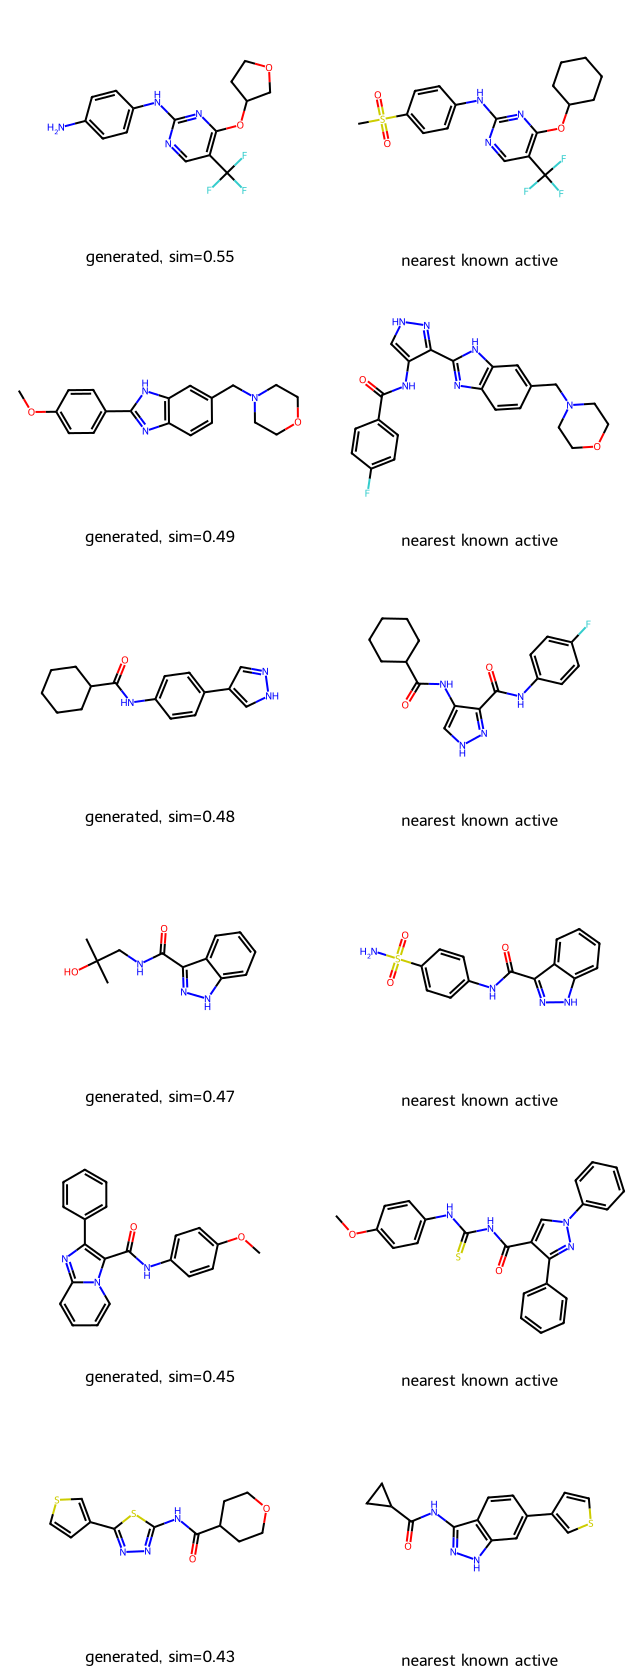

In [24]:
N_SHOW = 6
top_pairs = gen_df.sort_values("nearest_active_sim", ascending=False).head(N_SHOW)

mols_to_draw = []
legends = []
for _, row in top_pairs.iterrows():
    gen_mol = Chem.MolFromSmiles(row["canonical_smiles"])
    act_row = baseline.iloc[row["nearest_active_idx"]]
    act_mol = Chem.MolFromSmiles(act_row["canonical_smiles"])
    
    mols_to_draw += [gen_mol, act_mol]
    legends += [
        f"generated, sim={row['nearest_active_sim']:.2f}",
        "nearest known active",
    ]

img = Draw.MolsToGridImage(
    mols_to_draw, molsPerRow=2, subImgSize=(320, 280), legends=legends, 
    returnPNG=False 
    )
img.save(str(ANALYSIS_DIR / f"{TARGET_NAME}_iter{ITERATION}_closest_pairs.png"))
img

PCA - Projecting generated molecules into actives' descriptor space

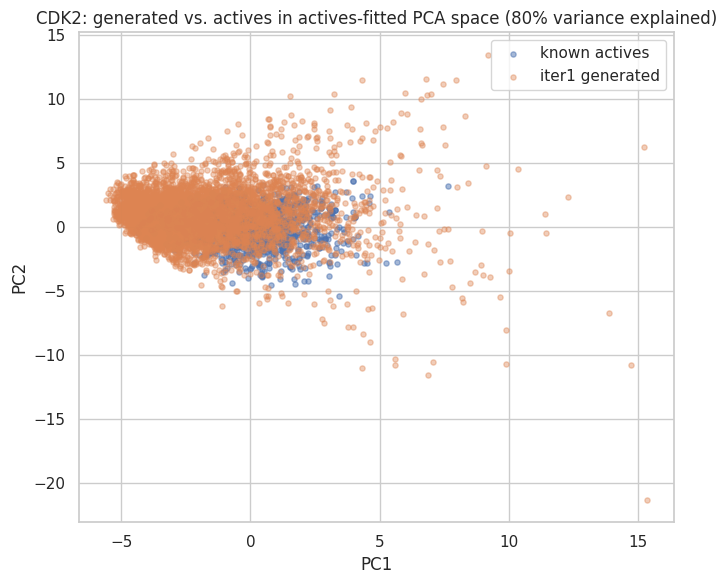

In [25]:
feature_cols = ["MW", "cLogP", "HBD", "HBA", "TPSA", "QED"]

scaler = StandardScaler().fit(baseline[feature_cols])
pca = PCA(n_components=2).fit(scaler.transform(baseline[feature_cols]))

act_pca = pca.transform(scaler.transform(baseline[feature_cols]))
gen_pca = pca.transform(scaler.transform(gen_df[feature_cols]))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(act_pca[:, 0], act_pca[:, 1], alpha=0.5, s=14, label="known actives")
ax.scatter(gen_pca[:, 0], gen_pca[:, 1], alpha=0.4, s=14,
           label=f"iter{ITERATION} generated")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"{TARGET_NAME}: generated vs. actives in actives-fitted PCA space "
             f"({pca.explained_variance_ratio_.sum():.0%} variance explained)")
ax.legend()
fig.tight_layout()
fig.savefig(ANALYSIS_DIR / f"{TARGET_NAME}_iter{ITERATION}_pca_comparison.png", 
            dpi=150, bbox_inches="tight")
plt.show()

PAINS screening on closest candidates

In [26]:
params = FilterCatalog.FilterCatalogParams()
params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS)
pains_catalog = FilterCatalog.FilterCatalog(params)

def pains_flags(smiles_list):
    flagged = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        match = pains_catalog.GetFirstMatch(mol)
        flagged.append(match.GetDescription() if match else None)
    return flagged

top_pairs = top_pairs.copy()
top_pairs["pains_flag"] = pains_flags(top_pairs["canonical_smiles"])
top_pairs[["canonical_smiles", "nearest_active_sim", "pains_flag"]]

,canonical_smiles,nearest_active_sim,pains_flag
750,Nc1ccc(Nc2ncc(C(F)(F)F)c(OC3CCOC3)n2)cc1,0.548387,anil_no_alk(40)
4724,COc1ccc(-c2nc3ccc(CN4CCOCC4)cc3[nH]2)cc1,0.486111,None
4419,O=C(Nc1ccc(-c2cn[nH]c2)cc1)C1CCCCC1,0.481481,None
3757,CC(C)(O)CNC(=O)c1n[nH]c2ccccc12,0.470588,None
372,COc1ccc(NC(=O)c2c(-c3ccccc3)nc3ccccn23)cc1,0.453125,None
1551,O=C(Nc1nnc(-c2ccsc2)s1)C1CCOCC1,0.431034,None


Assembling and saving comparison profile

In [27]:
comparison_cols = [
    "canonical_smiles", "MW", "cLogP", "HBD", "HBA", "TPSA",
    "QED", "SA_score", "scaffold", "nearest_active_sim",
    ] + flag_cols

comparison = gen_df[comparison_cols]
comparison_out = ANALYSIS_DIR / f"{TARGET_NAME}_iter{ITERATION}_comparison_profile.csv"
comparison.to_csv(comparison_out, index=False)

print("saved:", comparison_out)
print(f"rediscovery hits (sim >= {THETA_HIT}):", len(hits))

saved: /content/REINVENT_Boltz_Pipeline/iterations/CDK2/1/analysis/CDK2_iter1_comparison_profile.csv
rediscovery hits (sim >= 0.85): 0


Bringing everything to laptop (figures, csv)

In [28]:
import shutil
from google.colab import files

zip_base = f"/content/{TARGET_NAME}_iter{ITERATION}_analysis"
shutil.make_archive(zip_base, "zip", ANALYSIS_DIR)
files.download(f"{zip_base}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>